# Prophet + MoE Boosting
Utilizes Prophet library from Meta as time series forecasting model for additive non-linear seasonal trends, then LightGBM to boost residual error

In [0]:
%pip install prophet holidays lightgbm

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import numpy as np
import pandas as pd
import pyspark.sql.functions as F
from pyspark.sql.types import StructType, StructField, TimestampType, DoubleType, FloatType, IntegerType
from prophet import Prophet
import lightgbm as lgb
import holidays
import logging
import warnings

warnings.filterwarnings("ignore")
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

In [0]:
# PROPHET + LightGBM HYBRID  (v8.1 — Selective Merge)

# v7 feature richness  +  v8 architectural improvements:
#   Stage 1 — Prophet (~7 macro regressors): ext forecasts, DOY Fourier,
#             growth trend, conditional seasonalities. Stiffer priors (12)
#             so it intentionally leaves residual for LGB.
#   Stage 2 — LightGBM (~35 features): lags, rolling, night valley, solar,
#             calendar, interactions. Regularized (subsample + colsample).
# Supports extrapolation: if predict_end > data boundary, extends with
# future timestamps and fetches external forecasts for the future period.


MADRID_LAT, MADRID_LON = 40.4168, -3.7038
DST_SPRING = pd.Timestamp('2025-03-30')
DST_AUTUMN = pd.Timestamp('2025-10-26')
IPD = 96  # intervals per day (15-min)

class EnergyConsumptionModel:
    def __init__(self):
        self.prophet_model = None
        self.lgb_model = None

    @staticmethod
    def _solar_geometry(dt_series, lat=MADRID_LAT, lon=MADRID_LON):
        doy = dt_series.dt.dayofyear
        decl = np.radians(23.45 * np.sin(np.radians(360 / 365 * (doy - 81))))
        lat_r = np.radians(lat)
        ha = np.degrees(np.arccos(np.clip(-np.tan(lat_r) * np.tan(decl), -1, 1)))
        noon = 12.0 - lon / 15
        return noon - ha / 15, noon + ha / 15

    def _build_holiday_df(self, years):
        rows = []
        es_hol = holidays.ES(years=years)
        for date, name in sorted(es_hol.items()):
            rows.append({'holiday': name, 'ds': pd.Timestamp(date),
                         'lower_window': 0, 'upper_window': 1})
        for date in sorted(es_hol.keys()):
            dt = pd.Timestamp(date); dow = dt.dayofweek
            if dow == 1:
                rows.append({'holiday': 'puente', 'ds': dt - pd.Timedelta(days=1),
                             'lower_window': 0, 'upper_window': 0})
            elif dow == 3:
                rows.append({'holiday': 'puente', 'ds': dt + pd.Timedelta(days=1),
                             'lower_window': 0, 'upper_window': 0})
        return pd.DataFrame(rows)

    def _add_external_features(self, main_df, spark):
        tables = [
            ("datathon.shared.demand_forecast", "demand"),
            ("datathon.shared.pv_production_forecast", "pv"),
            ("datathon.shared.wind_production_forecast", "wind")
        ]
        for tbl, prefix in tables:
            try:
                ext = spark.table(tbl).withColumn(
                    "datetime_15min",
                    F.from_unixtime(F.unix_timestamp(F.col("datetime_local"))
                                    - (F.unix_timestamp(F.col("datetime_local")) % 900)
                    ).cast("timestamp"))
                num_cols = [f.name for f in ext.schema.fields
                            if isinstance(f.dataType, (DoubleType, FloatType, IntegerType))]
                if num_cols:
                    aggs = [F.avg(c).alias(f"{prefix}_{c}") for c in num_cols]
                    main_df = main_df.join(
                        ext.groupBy("datetime_15min").agg(*aggs),
                        on="datetime_15min", how="left")
            except Exception:
                pass
        return main_df

    def _add_all_features(self, df_pd):
        es_hol = holidays.ES(years=sorted(df_pd['ds'].dt.year.unique().tolist()))
        df_pd['date'] = df_pd['ds'].dt.date

        hour    = df_pd['ds'].dt.hour
        minute  = df_pd['ds'].dt.minute
        month   = df_pd['ds'].dt.month
        dow     = df_pd['ds'].dt.dayofweek
        doy     = df_pd['ds'].dt.dayofyear
        is_hol  = df_pd['date'].apply(lambda x: x in es_hol)
        hour_frac = hour + minute / 60.0

        # Conditional seasonality (Prophet)
        df_pd['cond_workday']    = (~dow.isin([5, 6]) & ~is_hol)
        df_pd['cond_saturday']   = ((dow == 5) & ~is_hol)
        df_pd['cond_sunday_hol'] = ((dow == 6) | is_hol)

        # Prophet Macro Regressors
        # DOY Fourier — yearly cycle proxy (only 11 months of data)
        df_pd['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
        df_pd['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)
        # Growth trend (2.6% annual)
        d0 = df_pd['ds'].min()
        df_pd['growth_trend'] = (df_pd['ds'] - d0).dt.total_seconds() / (365.25 * 86400)
        # Demand rolling 24h (exogenous forecast, no leakage)
        dem_cols = [c for c in df_pd.columns if c.startswith('demand_')]
        if dem_cols:
            df_pd['demand_roll_24h'] = df_pd[dem_cols[0]].rolling(IPD, min_periods=1).mean()

        # Leakage-safe lags and rolling features (shift ≥ 2 days)
        shift_2d = 2 * IPD  # 192 intervals
        df_pd['lag_2d']  = df_pd['y'].shift(shift_2d)
        df_pd['lag_7d']  = df_pd['y'].shift(7 * IPD)
        df_pd['lag_14d'] = df_pd['y'].shift(14 * IPD)

        shifted_y = df_pd['y'].shift(shift_2d)
        df_pd['rolling_24h_mean'] = shifted_y.rolling(IPD, min_periods=1).mean()
        df_pd['rolling_24h_std']  = shifted_y.rolling(IPD, min_periods=1).std().fillna(0)
        df_pd['rolling_7d_mean']  = shifted_y.rolling(7 * IPD, min_periods=1).mean()
        df_pd['rolling_7d_std']   = shifted_y.rolling(7 * IPD, min_periods=1).std().fillna(0)

        # Night valley fix
        df_pd['is_deep_night']     = ((hour >= 3) & (hour <= 6)).astype(float)
        df_pd['night_depth_curve'] = np.maximum(0, 1 - ((hour_frac - 4.5) / 3.0) ** 2)
        df_pd['night_x_workday']   = df_pd['is_deep_night'] * df_pd['cond_workday'].astype(float)

        # Solar geometry features
        sr, ss = self._solar_geometry(df_pd['ds'])
        df_pd['is_daylight']       = ((hour_frac >= sr) & (hour_frac <= ss)).astype(float)
        df_pd['min_since_sunrise'] = np.maximum(0, (hour_frac - sr) * 60)
        df_pd['is_twilight'] = (
            ((hour_frac >= sr - 0.5) & (hour_frac < sr + 0.5)) |
            ((hour_frac >= ss - 0.5) & (hour_frac < ss + 0.5))
        ).astype(float)

        # Calendar & lifestyle features
        df_pd['is_monday']       = (dow == 0).astype(float)
        df_pd['is_siesta']       = ((hour >= 13) & (hour <= 16) & df_pd['cond_workday']).astype(float)
        df_pd['is_wkday_eve_pk'] = ((hour >= 18) & (hour <= 22) & df_pd['cond_workday']).astype(float)
        df_pd['hour_x_weekend']  = hour_frac * dow.isin([5, 6]).astype(float)
        df_pd['hour_x_saturday'] = hour_frac * (dow == 5).astype(float)

        # Spanish daily regime
        df_pd['day_regime'] = np.select(
            [hour_frac < 7, hour_frac < 13, hour_frac < 17, hour_frac < 22],
            [0, 1, 2, 3], default=0).astype(float)
        df_pd['regime_x_weekend'] = df_pd['day_regime'] * dow.isin([5, 6]).astype(float)

        # Interactions
        pv_cols = [c for c in df_pd.columns if c.startswith('pv_')]
        df_pd['pv_x_daylight'] = df_pd[pv_cols[0]] * df_pd['is_daylight'] if pv_cols else 0.0

        df_pd['hxd_ss'] = np.sin(2*np.pi*hour_frac/24) * np.sin(2*np.pi*dow/7)
        df_pd['hxd_cc'] = np.cos(2*np.pi*hour_frac/24) * np.cos(2*np.pi*dow/7)

        df_pd['dst_adjustment'] = df_pd['ds'].apply(
            lambda x: np.exp(-min(abs((x - DST_SPRING).days),
                                 abs((x - DST_AUTUMN).days)) / 7.0))

        # Nonlinear demand (temperature proxy)
        if dem_cols:
            df_pd['demand_value_sq'] = df_pd[dem_cols[0]] ** 2

        # Numeric calendar for LGBM
        df_pd['feat_hour']  = hour.astype(float)
        df_pd['feat_dow']   = dow.astype(float)
        df_pd['feat_month'] = month.astype(float)

        # NaN handling
        lag_roll_cols = ['lag_2d', 'lag_7d', 'lag_14d',
                         'rolling_24h_mean', 'rolling_24h_std',
                         'rolling_7d_mean', 'rolling_7d_std']
        for c in lag_roll_cols:
            if c in df_pd.columns:
                df_pd[c] = df_pd[c].bfill().ffill().fillna(0)

        return df_pd

    def predict(self, df, predict_start, predict_end, train_cutoff=None):
        from pyspark.sql import SparkSession
        spark = SparkSession.builder.getOrCreate()

        # Spark aggregation
        df = df.withColumn("datetime_15min",
            F.from_unixtime(F.unix_timestamp("datetime_local")
                            - (F.unix_timestamp("datetime_local") % 900)
            ).cast("timestamp"))
        agg_df = df.groupBy("datetime_15min").agg(F.sum("active_kw").alias("target_kw"))
        agg_df = self._add_external_features(agg_df, spark)

        df_pd = agg_df.toPandas()
        df_pd['datetime_15min'] = pd.to_datetime(df_pd['datetime_15min'])
        df_pd = df_pd.sort_values('datetime_15min').reset_index(drop=True)
        df_pd['target_kw'] = df_pd['target_kw'].interpolate('linear', limit_direction='both')
        df_pd['ds'] = df_pd['datetime_15min']
        df_pd['y']  = df_pd['target_kw']

        # Extend into future if predict_end > data boundary
        data_end    = df_pd['ds'].max()
        pred_end_ts = pd.Timestamp(predict_end)
        if pred_end_ts > data_end + pd.Timedelta(hours=1):
            print(f"Extending forecast horizon: {data_end.date()} \u2192 {pred_end_ts.date()}")
            future_ts = pd.date_range(
                data_end + pd.Timedelta(minutes=15), pred_end_ts, freq="15min")
            future_rows = pd.DataFrame({
                'datetime_15min': future_ts, 'ds': future_ts,
                'target_kw': np.nan, 'y': np.nan})
            # Fetch external forecasts for the future period
            ext_tables = [
                ("datathon.shared.demand_forecast", "demand"),
                ("datathon.shared.pv_production_forecast", "pv"),
                ("datathon.shared.wind_production_forecast", "wind")]
            for tbl, prefix in ext_tables:
                try:
                    ext = spark.table(tbl).withColumn(
                        "datetime_15min",
                        F.from_unixtime(F.unix_timestamp(F.col("datetime_local"))
                                        - (F.unix_timestamp(F.col("datetime_local")) % 900)
                        ).cast("timestamp")
                    ).filter(F.col("datetime_15min") > F.lit(data_end))
                    num_cols = [f.name for f in ext.schema.fields
                                if isinstance(f.dataType, (DoubleType, FloatType, IntegerType))]
                    if num_cols:
                        ext_pd = ext.groupBy("datetime_15min").agg(
                            *[F.avg(c).alias(f"{prefix}_{c}") for c in num_cols]
                        ).toPandas()
                        ext_pd['datetime_15min'] = pd.to_datetime(ext_pd['datetime_15min'])
                        future_rows = future_rows.merge(
                            ext_pd, on='datetime_15min', how='left')
                except Exception:
                    pass
            df_pd = pd.concat([df_pd, future_rows], ignore_index=True)
            df_pd = df_pd.sort_values('ds').reset_index(drop=True)
            print(f"  Extended to {len(future_rows):,} future intervals "
                  f"({future_ts[0].date()} \u2192 {future_ts[-1].date()})")

        # Fill external nulls
        ext_cols = [c for c in df_pd.columns if c.startswith(('demand_', 'pv_', 'wind_'))]
        for c in ext_cols:
            df_pd[c] = df_pd[c].ffill().fillna(0)

        # Feature engineering
        df_pd = self._add_all_features(df_pd)

        # Feature Segregation 
        # Prophet: macro drivers only (non-collinear, smooth)
        PROPHET_REGS = [c for c in ext_cols if c in df_pd.columns] + [
            'doy_sin', 'doy_cos', 'growth_trend'
        ]
        if 'demand_roll_24h' in df_pd.columns:
            PROPHET_REGS.append('demand_roll_24h')
        PROPHET_REGS = [c for c in PROPHET_REGS if c in df_pd.columns]

        # LGBM: full feature set (lags, rolling, night, solar, interactions)
        LGB_FEATURES = PROPHET_REGS + [
            # Load history (leakage-safe)
            'lag_2d', 'lag_7d', 'lag_14d',
            'rolling_24h_mean', 'rolling_24h_std', 'rolling_7d_mean', 'rolling_7d_std',
            # Night valley
            'is_deep_night', 'night_depth_curve', 'night_x_workday',
            # Solar geometry
            'is_daylight', 'min_since_sunrise', 'is_twilight',
            # Calendar & lifestyle
            'feat_hour', 'feat_dow', 'feat_month', 'is_monday',
            'is_siesta', 'is_wkday_eve_pk', 'hour_x_weekend', 'hour_x_saturday',
            'day_regime', 'regime_x_weekend',
            # Interactions
            'pv_x_daylight', 'hxd_ss', 'hxd_cc', 'dst_adjustment',
        ]
        if 'demand_value_sq' in df_pd.columns:
            LGB_FEATURES.append('demand_value_sq')
        LGB_FEATURES = [c for c in LGB_FEATURES if c in df_pd.columns]

        # Train / test split
        cutoff = pd.Timestamp(train_cutoff) if train_cutoff else pd.Timestamp(predict_start)
        train_mask = df_pd['ds'] < cutoff
        train = df_pd[train_mask].copy()

        print(f"Prophet regressors: {len(PROPHET_REGS)}  |  LGB features: {len(LGB_FEATURES)}")
        print(f"Training on {len(train):,} rows (up to {cutoff})")

        # Prophet (macro baseline)
        holiday_df = self._build_holiday_df(list(range(2024, 2028)))

        m = Prophet(
            growth='flat', yearly_seasonality=False,
            weekly_seasonality=False, daily_seasonality=False,
            holidays=holiday_df, holidays_prior_scale=5.0,
            seasonality_prior_scale=12.0,   # stiffer than v7(15), leaves residual
            seasonality_mode='additive')

        m.add_seasonality(name='daily_workday',    period=1, fourier_order=20,
                          condition_name='cond_workday')
        m.add_seasonality(name='daily_saturday',   period=1, fourier_order=10,
                          condition_name='cond_saturday')
        m.add_seasonality(name='daily_sunday_hol', period=1, fourier_order=10,
                          condition_name='cond_sunday_hol')
        m.add_seasonality(name='weekly', period=7, fourier_order=3)

        for col in PROPHET_REGS:
            m.add_regressor(col, mode='additive', prior_scale=10.0)

        print("Fitting Prophet (macro drivers)...")
        m.fit(train)
        self.prophet_model = m
        print("Prophet fit complete.")

        # Prophet predict full range (train + test + future)
        pred_start = pd.Timestamp(predict_start)
        pred_end   = pd.Timestamp(predict_end)
        keep = ['ds'] + PROPHET_REGS + ['cond_workday', 'cond_saturday', 'cond_sunday_hol']
        full_future = df_pd[
            (df_pd['ds'] >= df_pd['ds'].min()) & (df_pd['ds'] <= pred_end)
        ][keep].copy()
        print(f"Prophet predicting {len(full_future):,} intervals...")
        prophet_forecast = m.predict(full_future)

        df_pd = df_pd.merge(
            prophet_forecast[['ds', 'yhat']].rename(columns={'yhat': 'prophet_yhat'}),
            on='ds', how='left')

        # Prophet-only diagnostic
        p_train_mae = np.mean(np.abs(df_pd.loc[train_mask, 'y'] - df_pd.loc[train_mask, 'prophet_yhat']))
        print(f"Prophet-only train MAE: {p_train_mae:,.0f} kW")

        # LightGBM residual correction
        lgb_train = df_pd[train_mask & df_pd['prophet_yhat'].notna()].copy()
        lgb_train['residual'] = lgb_train['y'] - lgb_train['prophet_yhat']

        X_train = lgb_train[LGB_FEATURES].fillna(0)
        y_train = lgb_train['residual']
        print(f"Training LGB on {len(X_train):,} residuals "
              f"(mean |residual|: {y_train.abs().mean():,.0f} kW)")

        lgb_model = lgb.LGBMRegressor(
            n_estimators=400, learning_rate=0.04, max_depth=4,
            num_leaves=8, min_child_samples=25,
            subsample=0.8,            # row bagging  (from v8)
            colsample_bytree=0.7,     # feature bagging (from v8)
            reg_alpha=0.3,            # L1 regularization
            reg_lambda=0.3,           # L2 regularization
            objective='regression_l1',
            random_state=42, verbosity=-1)

        lgb_model.fit(X_train, y_train)
        self.lgb_model = lgb_model
        print("LGB residual model fit complete.")

        # Feature importances
        imp = pd.Series(lgb_model.feature_importances_, index=LGB_FEATURES)
        print("\nLGB top features (residual correction):")
        for feat, val in imp.nlargest(15).items():
            print(f"  {feat:30s}  {val:>6d}")

        # Inference
        pred_mask = (df_pd['ds'] >= pred_start) & (df_pd['ds'] <= pred_end)
        out = df_pd[pred_mask][['ds', 'prophet_yhat'] + LGB_FEATURES].copy()

        lgb_correction = lgb_model.predict(out[LGB_FEATURES].fillna(0))
        out['prediction'] = (out['prophet_yhat'] + lgb_correction).clip(lower=0)

        print(f"\nPredicting {len(out):,} intervals ({pred_start} \u2192 {pred_end})")

        result = out[['ds', 'prediction']].rename(columns={'ds': 'datetime_15min'})
        schema = StructType([
            StructField("datetime_15min", TimestampType(), True),
            StructField("prediction", DoubleType(), True)])
        return spark.createDataFrame(result, schema=schema)

Prophet regressors: 7  |  LGB features: 35
Training on 29,176 rows (up to 2025-11-01 00:00:00)
Fitting Prophet (macro drivers)...


08:35:14 - cmdstanpy - INFO - Chain [1] start processing
08:35:18 - cmdstanpy - INFO - Chain [1] done processing


Prophet fit complete.
Prophet predicting 31,961 intervals...
Prophet-only train MAE: 16,535 kW
Training LGB on 29,176 residuals (mean |residual|: 16,535 kW)
LGB residual model fit complete.

LGB top features (residual correction):
  doy_sin                            389
  doy_cos                            262
  growth_trend                       231
  rolling_7d_mean                    174
  min_since_sunrise                  165
  dst_adjustment                     156
  demand_roll_24h                    128
  demand_value                       120
  wind_value                         114
  rolling_24h_mean                   103
  feat_hour                          103
  lag_2d                              94
  rolling_7d_std                      90
  feat_dow                            83
  pv_value                            74

Predicting 31,961 intervals (2025-01-01 00:00:00 → 2025-11-30 00:00:00)

════════════════════════════════════════════════════════════
  Prophet GAM — Eva

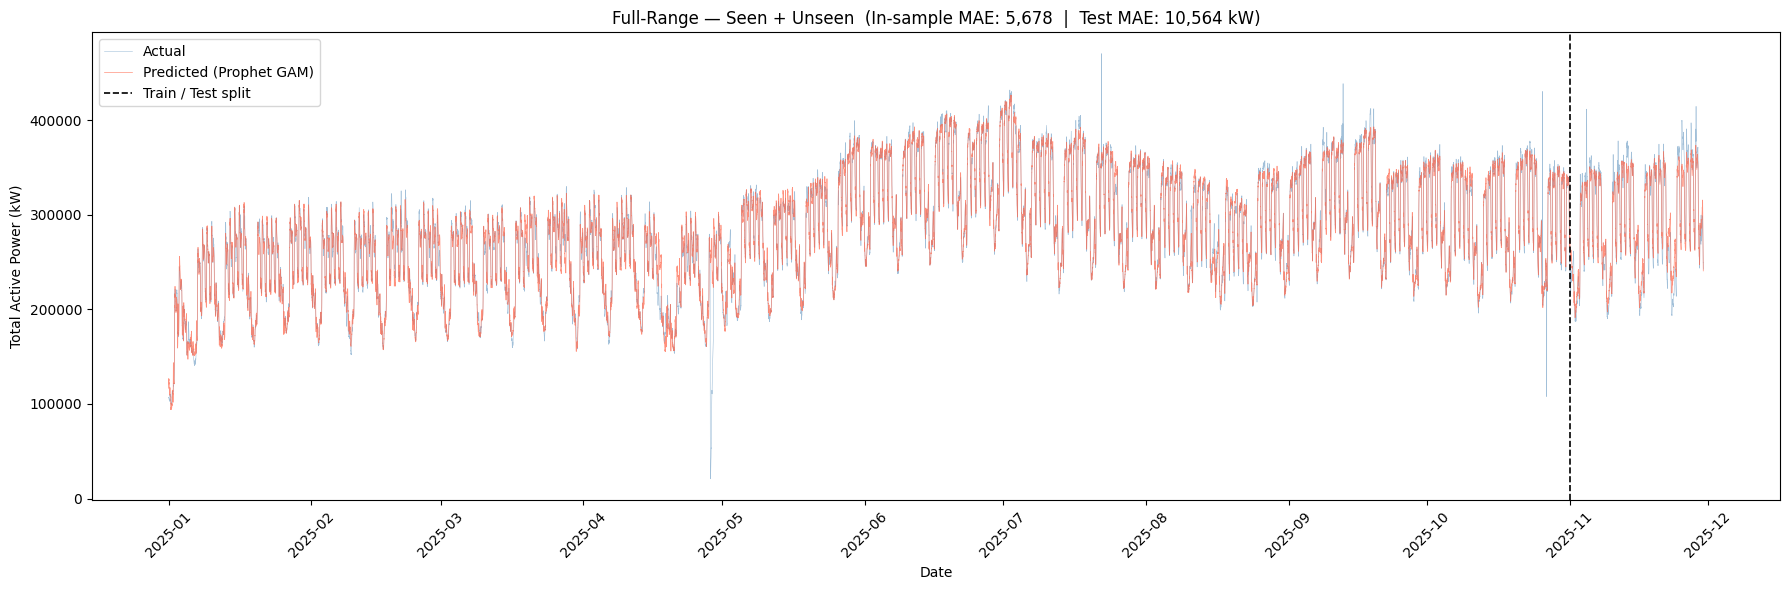

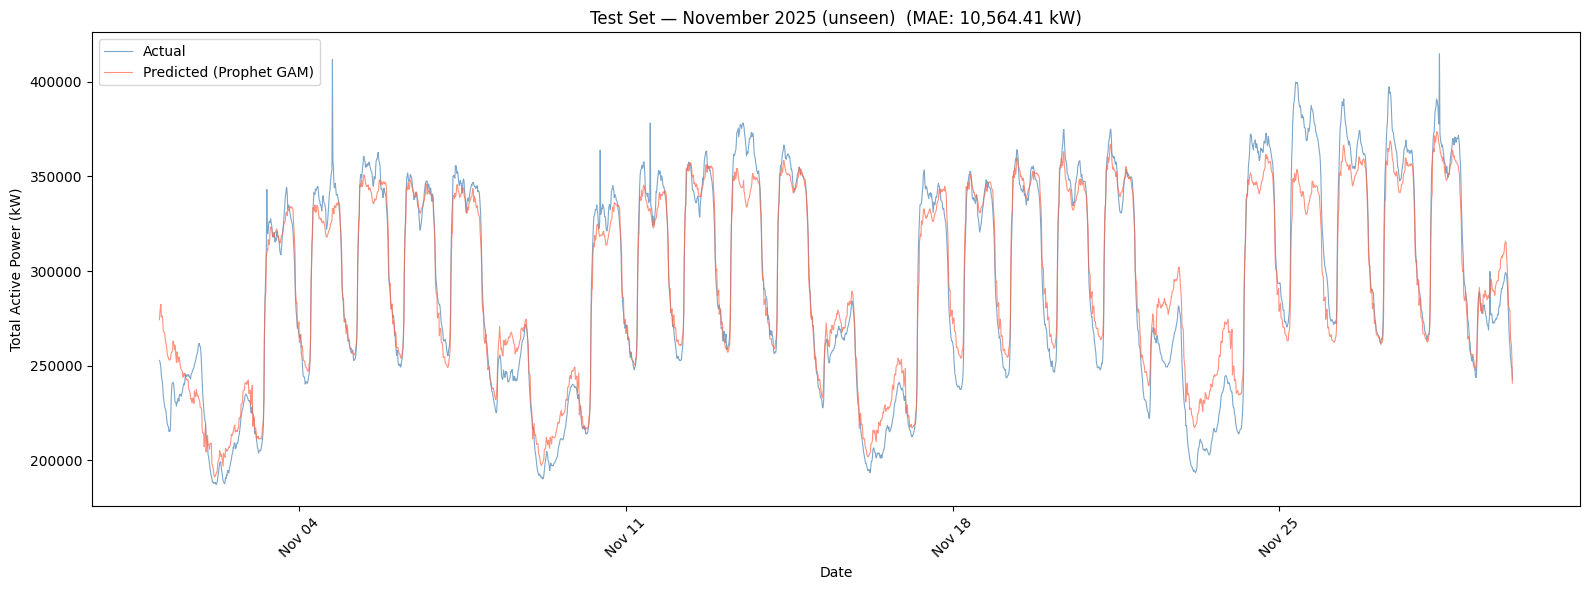



════════════════════════════════════════════════════════════
  EXTRAPOLATION: Training on ALL data (Jan–Nov 2025)
  Forecasting to 2026-03-01
════════════════════════════════════════════════════════════
Extending forecast horizon: 2025-11-30 → 2026-03-01
  Extended to 8,641 future intervals (2025-12-01 → 2026-03-01)
Prophet regressors: 7  |  LGB features: 35
Training on 32,056 rows (up to 2025-12-01 00:00:00)
Fitting Prophet (macro drivers)...


08:35:56 - cmdstanpy - INFO - Chain [1] start processing
08:36:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet fit complete.
Prophet predicting 40,697 intervals...
Prophet-only train MAE: 16,163 kW
Training LGB on 32,056 residuals (mean |residual|: 16,163 kW)
LGB residual model fit complete.

LGB top features (residual correction):
  doy_sin                            388
  growth_trend                       258
  doy_cos                            233
  dst_adjustment                     179
  min_since_sunrise                  159
  rolling_7d_mean                    153
  demand_value                       140
  rolling_24h_mean                   126
  demand_roll_24h                    120
  wind_value                         111
  feat_hour                          103
  lag_7d                              91
  lag_2d                              86
  rolling_7d_std                      86
  pv_value                            75

Predicting 40,697 intervals (2025-01-01 00:00:00 → 2026-03-01 00:00:00)
  Extrapolation period: 2025-12-01 → 2026-03-01
  Extrapolated intervals: 8,641
 

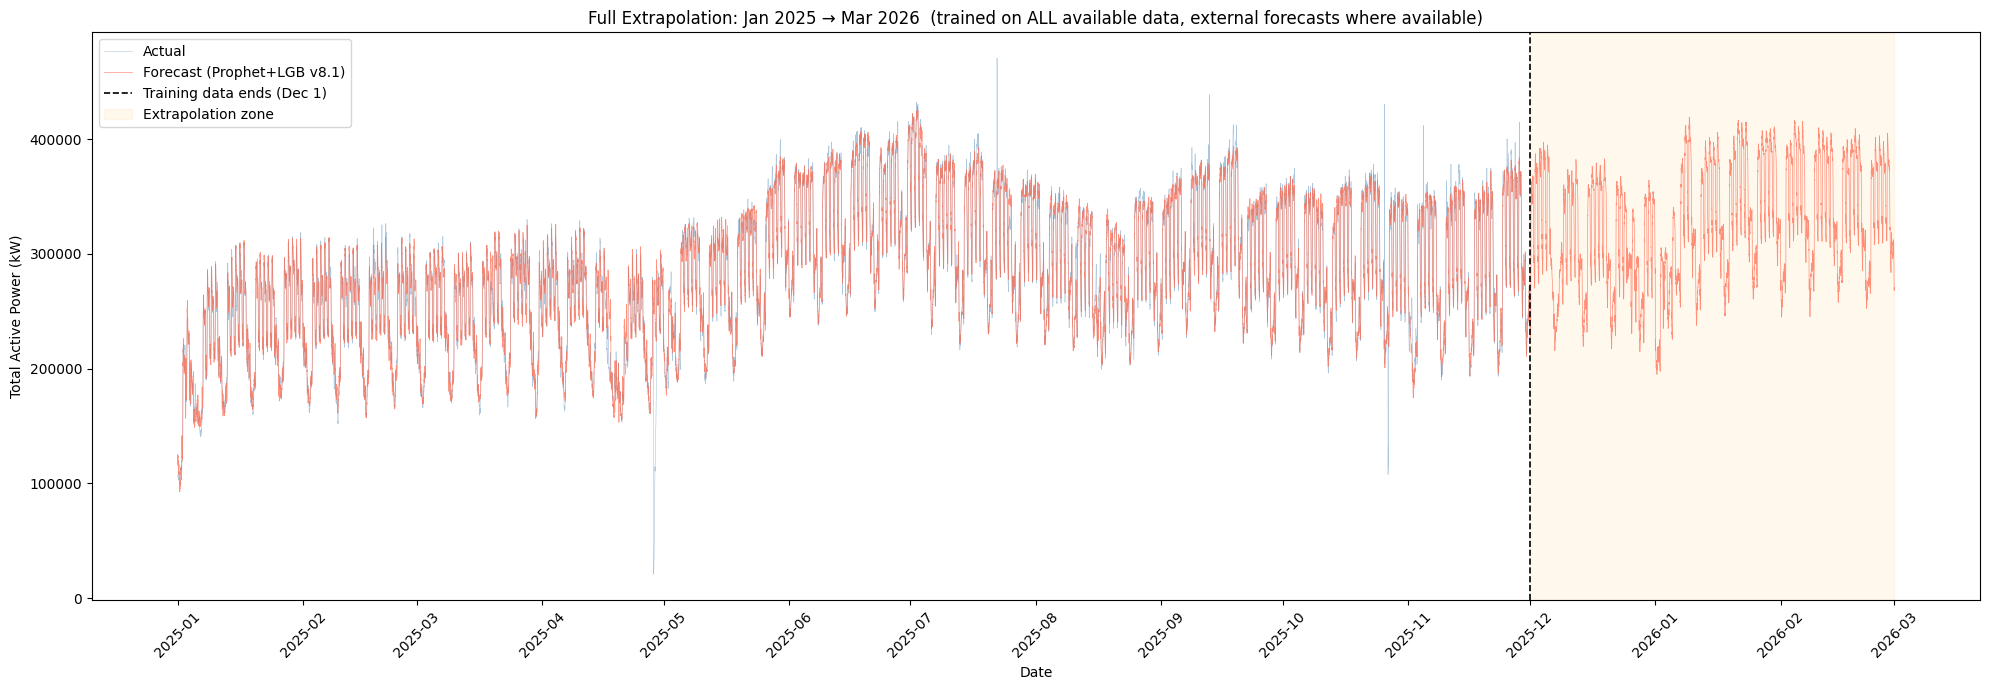

In [0]:
# EVALUATION: Prophet GAM on Iberian Energy Consumption
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load raw consumption data
raw_df = spark.table("datathon.shared.client_consumption")

# Portfolio-level actuals (15-min bins)
actuals_sdf = raw_df.withColumn(
    "datetime_15min",
    F.from_unixtime(
        F.unix_timestamp("datetime_local") - (F.unix_timestamp("datetime_local") % 900)
    ).cast("timestamp")
).groupBy("datetime_15min").agg(F.sum("active_kw").alias("actual_kw"))

actuals_pd = actuals_sdf.toPandas()
actuals_pd["datetime_15min"] = pd.to_datetime(actuals_pd["datetime_15min"])
actuals_pd = actuals_pd.sort_values("datetime_15min").reset_index(drop=True)

# Date boundaries
PREDICT_START = "2025-01-01"   # predict full range
PREDICT_END   = "2025-11-30"
TRAIN_CUTOFF  = "2025-11-01"   # train on Jan–Oct
TEST_START    = pd.Timestamp("2025-11-01")

# Fit & predict
model = EnergyConsumptionModel()
preds_sdf = model.predict(raw_df, PREDICT_START, PREDICT_END, train_cutoff=TRAIN_CUTOFF)
preds_pd = preds_sdf.toPandas()
preds_pd["datetime_15min"] = pd.to_datetime(preds_pd["datetime_15min"])
preds_pd = preds_pd.sort_values("datetime_15min").reset_index(drop=True)

# Merge & evaluate
merged = preds_pd.merge(actuals_pd, on="datetime_15min", how="left")
valid = merged.dropna(subset=["actual_kw", "prediction"])

seen_mask   = valid["datetime_15min"] < TEST_START
unseen_mask = valid["datetime_15min"] >= TEST_START

seen_mae = np.mean(np.abs(valid.loc[seen_mask, "actual_kw"] - valid.loc[seen_mask, "prediction"]))
test_mae = np.mean(np.abs(valid.loc[unseen_mask, "actual_kw"] - valid.loc[unseen_mask, "prediction"]))
full_mae = np.mean(np.abs(valid["actual_kw"] - valid["prediction"]))

print("\n" + "═" * 60)
print("  Prophet GAM — Evaluation Summary")
print("  Trained on Jan–Oct 2025 (~10 months)")
print("═" * 60)
print(f"  In-sample  MAE (Jan–Oct):  {seen_mae:>12,.2f} kW")
print(f"  Test MAE   (November):     {test_mae:>12,.2f} kW")
print(f"  Full-range MAE (Jan–Nov):  {full_mae:>12,.2f} kW")
print(f"  Mean actual (test):        {valid.loc[unseen_mask, 'actual_kw'].mean():>12,.2f} kW")
print(f"  Test MAE as % of mean:     {100 * test_mae / valid.loc[unseen_mask, 'actual_kw'].mean():>11.2f}%")
print("═" * 60)

# PLOTS
# Plot 1: Full-range (Jan–Nov, train/test split)
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(merged["datetime_15min"], merged["actual_kw"],
        label="Actual", alpha=0.5, linewidth=0.4, color="steelblue")
ax.plot(merged["datetime_15min"], merged["prediction"],
        label="Predicted (Prophet GAM)", alpha=0.7, linewidth=0.5, color="tomato")
ax.axvline(TEST_START, color="black", linestyle="--", linewidth=1.2, label="Train / Test split")
ax.set_title(f"Full-Range — Seen + Unseen  (In-sample MAE: {seen_mae:,.0f}  |  Test MAE: {test_mae:,.0f} kW)")
ax.set_xlabel("Date")
ax.set_ylabel("Total Active Power (kW)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: November (test)
test_df = merged[merged["datetime_15min"] >= TEST_START]
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test_df["datetime_15min"], test_df["actual_kw"],
        label="Actual", alpha=0.7, linewidth=0.8, color="steelblue")
ax.plot(test_df["datetime_15min"], test_df["prediction"],
        label="Predicted (Prophet GAM)", alpha=0.7, linewidth=0.8, color="tomato")
ax.set_title(f"Test Set — November 2025 (unseen)  (MAE: {test_mae:,.2f} kW)")
ax.set_xlabel("Date")
ax.set_ylabel("Total Active Power (kW)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 3: EXTRAPOLATION — Train on ALL data, forecast to Mar 2026
# Uses external forecasts (demand/pv/wind) for Dec–Feb where available,
# forward-fills load lags from last known November actuals.
print("\n\n" + "═" * 60)
print("  EXTRAPOLATION: Training on ALL data (Jan–Nov 2025)")
print("  Forecasting to 2026-03-01")
print("═" * 60)

EXTRAP_END = "2026-03-01"
DATA_BOUNDARY = pd.Timestamp("2025-12-01")  # actuals end ~ Nov 30

model_extrap = EnergyConsumptionModel()
extrap_preds_sdf = model_extrap.predict(
    raw_df, "2025-01-01", EXTRAP_END, train_cutoff="2025-12-01")

extrap_pd = extrap_preds_sdf.toPandas()
extrap_pd["datetime_15min"] = pd.to_datetime(extrap_pd["datetime_15min"])
extrap_pd = extrap_pd.sort_values("datetime_15min").reset_index(drop=True)

# Merge with actuals (available only through Nov 2025)
extrap_merged = extrap_pd.merge(actuals_pd, on="datetime_15min", how="left")

# Extrapolation zone stats
extrap_zone = extrap_merged[extrap_merged["datetime_15min"] >= DATA_BOUNDARY]
print(f"  Extrapolation period: {DATA_BOUNDARY.date()} \u2192 {EXTRAP_END}")
print(f"  Extrapolated intervals: {len(extrap_zone):,}")
print(f"  Mean forecast (Dec–Feb): {extrap_zone['prediction'].mean():,.0f} kW")
print(f"  Min forecast:  {extrap_zone['prediction'].min():,.0f} kW")
print(f"  Max forecast:  {extrap_zone['prediction'].max():,.0f} kW")

# Plot
fig, ax = plt.subplots(figsize=(20, 7))

# Actuals (where available)
act = extrap_merged.dropna(subset=["actual_kw"])
ax.plot(act["datetime_15min"], act["actual_kw"],
        label="Actual", alpha=0.45, linewidth=0.4, color="steelblue")

# Forecast (full range: Jan 2025 → Mar 2026)
ax.plot(extrap_merged["datetime_15min"], extrap_merged["prediction"],
        label="Forecast (Prophet+LGB v8.1)", alpha=0.7, linewidth=0.5, color="tomato")

# Data boundary
ax.axvline(DATA_BOUNDARY, color="black", linestyle="--", linewidth=1.2,
           label="Training data ends (Dec 1)")
ax.axvspan(DATA_BOUNDARY, extrap_merged["datetime_15min"].max(),
           alpha=0.07, color="orange", label="Extrapolation zone")

ax.set_title("Full Extrapolation: Jan 2025 \u2192 Mar 2026  "
             "(trained on ALL available data, external forecasts where available)")
ax.set_xlabel("Date")
ax.set_ylabel("Total Active Power (kW)")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Raw predictions: 31,961 rows (seen: 29,176, test: 2,785)

Swept 101 configs in 0.1s

Top 20 smoothing configs (sorted by TEST MAE):
  window   poly        full_mae        seen_mae        test_mae
------------------------------------------------------------------------
       9      4         6,021.6         5,594.5        10,495.9
       9      5         6,021.7         5,594.5        10,496.1
       7      2         6,026.5         5,599.1        10,503.2
       7      3         6,026.6         5,599.2        10,504.3
       5      2         6,043.2         5,616.1        10,517.5
       5      3         6,043.3         5,616.1        10,518.5
      11      4         6,056.7         5,630.3        10,523.3
      11      5         6,056.7         5,630.3        10,523.5
       3      1         6,016.4         5,585.9        10,525.8
      15      5         6,078.7         5,653.7        10,531.5
      15      4         6,078.7         5,653.7        10,531.6
       7      4         6,0

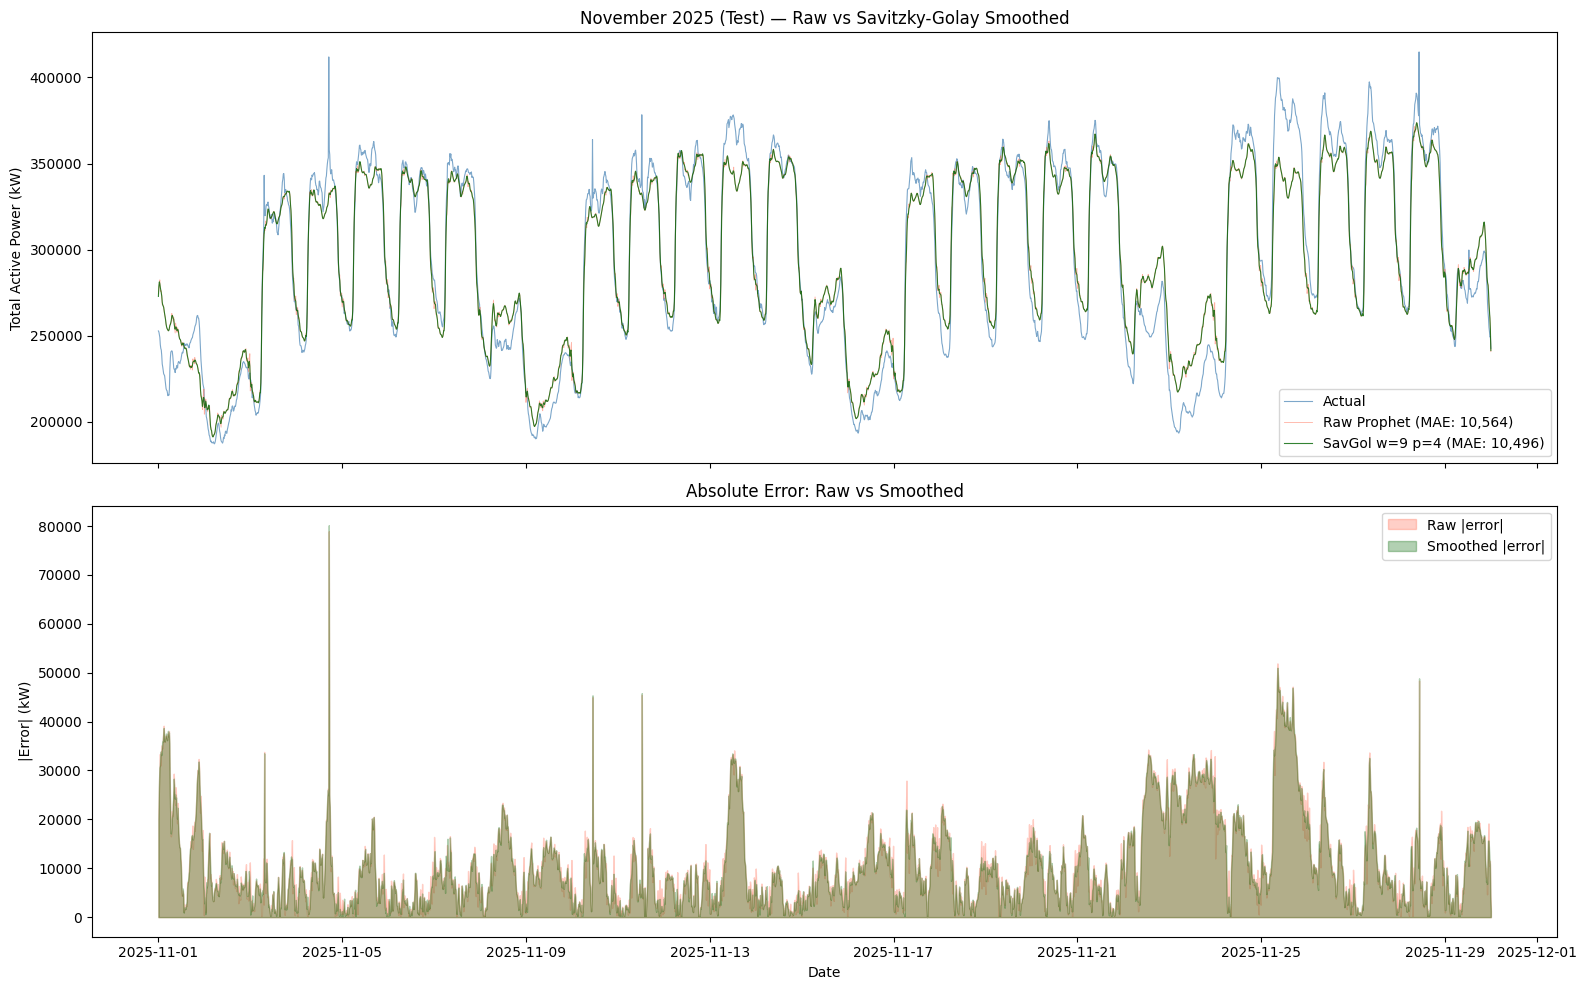

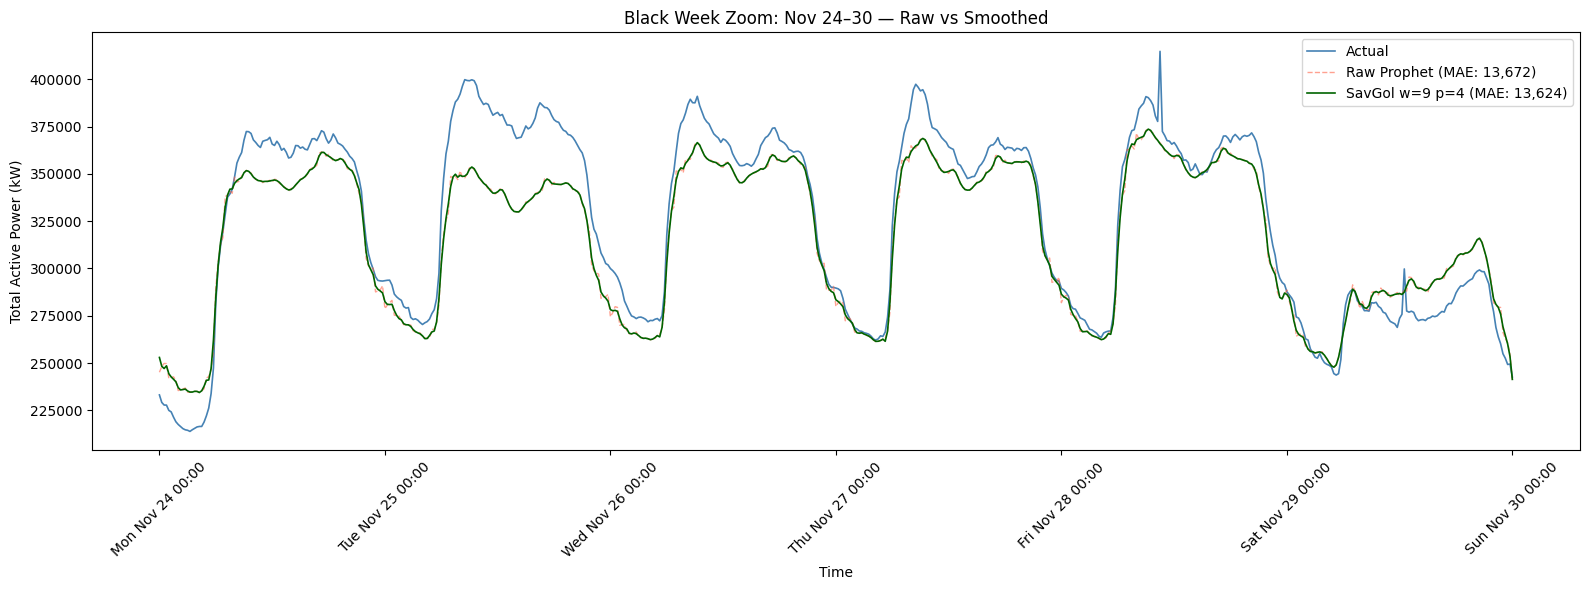

In [0]:
# SAVITZKY-GOLAY SMOOTHING SWEEP — post-hoc on raw Prophet predictions
# No retraining: operates on `merged` from evaluation cell
from scipy.signal import savgol_filter
from itertools import product
import time

TEST_START = pd.Timestamp("2025-11-01")

# Work on the full merged DataFrame from the evaluation cell
raw_merged = merged.dropna(subset=["actual_kw", "prediction"]).copy()
raw_vals   = raw_merged["prediction"].values
actual_vals = raw_merged["actual_kw"].values
seen_idx   = raw_merged["datetime_15min"] < TEST_START
test_idx   = raw_merged["datetime_15min"] >= TEST_START

print(f"Raw predictions: {len(raw_vals):,} rows "
      f"(seen: {seen_idx.sum():,}, test: {test_idx.sum():,})")

# Parameter grid
window_lengths = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 29, 33, 37, 41, 49, 57, 65, 73, 81, 97]
poly_orders    = [1, 2, 3, 4, 5]

results = []
t0 = time.time()

for wl, po in product(window_lengths, poly_orders):
    if po >= wl:        # polyorder must be < window_length
        continue
    if wl > len(raw_vals):
        continue
    try:
        smoothed = savgol_filter(raw_vals, window_length=wl, polyorder=po)
        errs = np.abs(actual_vals - smoothed)
        results.append({
            'window':   wl,
            'poly':     po,
            'full_mae': errs.mean(),
            'seen_mae': errs[seen_idx].mean(),
            'test_mae': errs[test_idx].mean(),
        })
    except Exception:
        pass

elapsed = time.time() - t0

# Sort & display top configs
res_df = pd.DataFrame(results).sort_values('test_mae')

print(f"\nSwept {len(results)} configs in {elapsed:.1f}s")
print(f"\nTop 20 smoothing configs (sorted by TEST MAE):")
print("=" * 72)
print(f"  {'window':>6}   {'poly':>4}      {'full_mae':>10}      {'seen_mae':>10}      {'test_mae':>10}")
print("-" * 72)
for _, r in res_df.head(20).iterrows():
    print(f"  {int(r['window']):>6}   {int(r['poly']):>4}      {r['full_mae']:>10,.1f}      {r['seen_mae']:>10,.1f}      {r['test_mae']:>10,.1f}")
print("=" * 72)

# Raw (unsmoothed) baseline
raw_full = np.abs(actual_vals - raw_vals).mean()
raw_seen = np.abs(actual_vals[seen_idx] - raw_vals[seen_idx]).mean()
raw_test = np.abs(actual_vals[test_idx] - raw_vals[test_idx]).mean()
print(f"\n  {'RAW':>6}   {'---':>4}      {raw_full:>10,.1f}      {raw_seen:>10,.1f}      {raw_test:>10,.1f}")

best = res_df.iloc[0]
print(f"\n\u2500\u2500 Best config: window={int(best['window'])}, poly={int(best['poly'])}")
print(f"   Test MAE improvement: {raw_test:,.1f} \u2192 {best['test_mae']:,.1f} kW "
      f"(\u0394 {raw_test - best['test_mae']:+,.1f}, {100*(raw_test - best['test_mae'])/raw_test:+.2f}%)")
print(f"   Full MAE improvement: {raw_full:,.1f} \u2192 {best['full_mae']:,.1f} kW "
      f"(\u0394 {raw_full - best['full_mae']:+,.1f}, {100*(raw_full - best['full_mae'])/raw_full:+.2f}%)")

# Visualize best smoothing on November test set
best_wl, best_po = int(best['window']), int(best['poly'])
best_smoothed = savgol_filter(raw_vals, window_length=best_wl, polyorder=best_po)

test_slice = raw_merged[test_idx].copy()
test_slice['smoothed'] = best_smoothed[test_idx.values]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Panel 1: Raw vs Smoothed vs Actual (November)
ax = axes[0]
ax.plot(test_slice['datetime_15min'], test_slice['actual_kw'],
        label='Actual', alpha=0.7, linewidth=0.8, color='steelblue')
ax.plot(test_slice['datetime_15min'], test_slice['prediction'],
        label=f'Raw Prophet (MAE: {raw_test:,.0f})', alpha=0.5, linewidth=0.6, color='tomato')
ax.plot(test_slice['datetime_15min'], test_slice['smoothed'],
        label=f'SavGol w={best_wl} p={best_po} (MAE: {best["test_mae"]:,.0f})',
        alpha=0.8, linewidth=0.8, color='darkgreen')
ax.set_title(f'November 2025 (Test) \u2014 Raw vs Savitzky-Golay Smoothed')
ax.set_ylabel('Total Active Power (kW)')
ax.legend()

# Panel 2: Absolute error comparison
ax = axes[1]
raw_err  = np.abs(test_slice['actual_kw'].values - test_slice['prediction'].values)
sg_err   = np.abs(test_slice['actual_kw'].values - test_slice['smoothed'].values)
ax.fill_between(test_slice['datetime_15min'], raw_err, alpha=0.3, color='tomato', label=f'Raw |error|')
ax.fill_between(test_slice['datetime_15min'], sg_err, alpha=0.3, color='darkgreen', label=f'Smoothed |error|')
ax.set_title('Absolute Error: Raw vs Smoothed')
ax.set_ylabel('|Error| (kW)')
ax.set_xlabel('Date')
ax.legend()

plt.tight_layout()
plt.show()

# Zoom: Black Week (Nov 24–30) with smoothing
zoom_start = pd.Timestamp("2025-11-24")
zoom_end   = pd.Timestamp("2025-11-30 23:59:59")
zoom = test_slice[(test_slice['datetime_15min'] >= zoom_start) &
                  (test_slice['datetime_15min'] <= zoom_end)]

if len(zoom) > 0:
    zoom_raw_mae = np.abs(zoom['actual_kw'] - zoom['prediction']).mean()
    zoom_sg_mae  = np.abs(zoom['actual_kw'] - zoom['smoothed']).mean()

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(zoom['datetime_15min'], zoom['actual_kw'],
            label='Actual', linewidth=1.2, color='steelblue')
    ax.plot(zoom['datetime_15min'], zoom['prediction'],
            label=f'Raw Prophet (MAE: {zoom_raw_mae:,.0f})',
            linewidth=1.0, alpha=0.6, color='tomato', linestyle='--')
    ax.plot(zoom['datetime_15min'], zoom['smoothed'],
            label=f'SavGol w={best_wl} p={best_po} (MAE: {zoom_sg_mae:,.0f})',
            linewidth=1.2, color='darkgreen')
    ax.set_title(f'Black Week Zoom: Nov 24\u201330 \u2014 Raw vs Smoothed')
    ax.set_xlabel('Time')
    ax.set_ylabel('Total Active Power (kW)')
    ax.legend()
    import matplotlib.dates as mdates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %b %d %H:%M'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()